In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [3]:
df = pd.read_csv('./data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

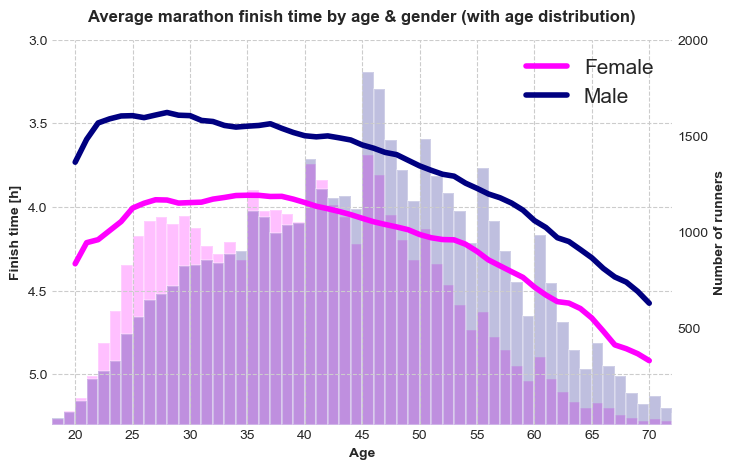

In [5]:
# fig
fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()
# subset
data = df.groupby(["Age", "M/F"])["Official Time"].mean().reset_index()
data = data[data['Age'] < 71]
# create plot
for MF in data["M/F"].unique():
    subset = data[data["M/F"] == MF].sort_values(by="Age")
    subset["Smooth"] = subset["Official Time"].rolling(3).mean()
    if MF == "M":
        c='navy'
        l='Male'
        a=0.25
    else: 
        c='magenta'
        l='Female'
        a=0.25
    ax2.hist(df["Age"][df["M/F"] == MF], bins=range(18,84,1), color=c, alpha=a, edgecolor='white', linewidth=1.5)
    ax1.plot(subset["Age"], subset["Smooth"], label=l, linewidth=4, color=c)
### ax1
## xy settings    
# x
ax1.set_xlabel("Age", weight='bold')
ax1.set_xlim(18,72)
ax1.set_xticks(range(20,71,5))
# y
ax1.set_ylabel("Finish time [h]", weight='bold')
ax1.set_ylim(3,5.3)
ax1.invert_yaxis()
### ax2
## xy settings    
# x
# y
ax2.set_ylabel("Number of runners", weight='bold')
ax2.set_ylim(0, ax2.get_ylim()[1] * 0.8)
ax2.set_yticks(range(500,2001,500))

## style
# ax1
ax1.set_title("Average marathon finish time by age & gender (with age distribution)", weight='bold', pad=13)
ax1.grid(True, linestyle='--', alpha=1)
ax1.set_zorder(3)
ax1.patch.set_visible(False)
ax1.legend(fontsize=15)
# ax2
ax2.set_zorder(2)
ax2.patch.set_visible(True)
ax2.grid(False)
# both
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.savefig("charts/plothist_age-finishtime_gender.png", dpi=300, bbox_inches='tight')
plt.show()